In [1]:
# Netflix Movies and TV Shows Dataset from Kaggle

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Data Quality & Missing Data

In [3]:
df = pd.read_csv('netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Unnamed: 12
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,NaN


In [4]:
df.shape


(8807, 13)

In [5]:
#to see the data info clearly
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8807 non-null   str    
 1   type          8807 non-null   str    
 2   title         8807 non-null   str    
 3   director      6173 non-null   str    
 4   cast          7982 non-null   str    
 5   country       7976 non-null   str    
 6   date_added    8797 non-null   str    
 7   release_year  8807 non-null   int64  
 8   rating        8803 non-null   str    
 9   duration      8804 non-null   str    
 10  listed_in     8807 non-null   str    
 11  description   8807 non-null   str    
 12  Unnamed: 12   0 non-null      float64
dtypes: float64(1), int64(1), str(11)
memory usage: 894.6 KB


In [6]:
df.describe()

,release_year,Unnamed: 12
count,8807.000000,0.0
mean,2014.180198,NaN
std,8.819312,NaN
min,1925.000000,NaN
25%,2013.000000,NaN
50%,2017.000000,NaN
75%,2019.000000,NaN
max,2021.000000,NaN


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
Unnamed: 12     8807
dtype: int64

In [9]:
#replacing the missing values

df['director'] = df['director'].fillna('unknown')
df['cast'] = df['cast'].fillna('unknown')
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['date_added'] = df['date_added'].fillna(df['date_added'].copy().bfill())

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Unnamed: 12
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",NaN
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,NaN
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,United States,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",NaN
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,NaN


In [10]:
df[df['rating'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Unnamed: 12
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,unknown,"Oprah Winfrey, Ava DuVernay",United States,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...,NaN
6827,s6828,TV Show,Gargantia on the Verdurous Planet,unknown,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel...",NaN
7312,s7313,TV Show,Little Lunch,unknown,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take...",NaN
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c...",NaN


In [11]:
#The movie can be a bit mature for children under 17
df.loc[df['show_id'] == 's5990','rating'] = 'TV-MA'

#The animation is suitable for teenagers and include some form of aggression
df.loc[df['show_id'] == 's6828', 'rating'] = 'PG-13'

#The series is suitable for middle and upper primary students according to
#the description
df.loc[df['show_id'] == 's7313', 'rating'] = 'PG'

#The movie is listed in the dramas category and the description showcase that
#it fits well in PG-13 rating
df.loc[df['show_id'] == 's7538', 'rating'] = 'PG-13'

In [12]:
df[df['duration'].isna()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Unnamed: 12
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi...",NaN
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...,NaN
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...,NaN


In [13]:
#The duration data is missing because it was incorrectly shifted into the rating column.This resulted in null values for duration and missing data for the actual ratings.
df.loc[df['show_id'] == 's5542', 'duration' ] = '74 min'
df.loc[df['show_id'] == 's5795', 'duration' ] = '84 min'
df.loc[df['show_id'] == 's5814', 'duration' ] = '66 min'

movie_rating=df[df['type'] == 'Movie']['rating'].mode()[0]
df.loc[df['show_id'] == 's5542', 'rating' ] = movie_rating
df.loc[df['show_id'] == 's5795', 'rating' ] = movie_rating
df.loc[df['show_id'] == 's5814', 'rating' ] = movie_rating

In [14]:
display(df[df['show_id']=='s5795'])

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Unnamed: 12
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,TV-MA,84 min,Movies,Emmy-winning comedy writer Louis C.K. brings h...,NaN


In [15]:
df['duration'].value_counts()

duration
1 Season     1793
2 Seasons     425
3 Seasons     199
90 min        152
94 min        146
             ... 
228 min         1
18 min          1
205 min         1
201 min         1
191 min         1
Name: count, Length: 220, dtype: int64

In [16]:

df = df.drop('Unnamed: 12', axis=1, errors='ignore')

In [17]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,United States,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [18]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

<h1>Data Types Formatting<h1>

In [19]:
unexpected_data=df[~df['type'].isin(['TV Show','Movie'])]
display(len(unexpected_data))

0

In [20]:
invalid_duration = df[~df['duration'].str.contains('min|mins|Season|Seasons', na=False, case=False)]
display(len(invalid_duration))

0

In [21]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [22]:
split_data = df['duration'].str.split(' ', expand=True)
df['duration_no'] = split_data[0]
df['duration_unit'] = split_data[1]
df['duration_no'] = pd.to_numeric(df['duration_no'], errors='coerce')
print(df[['duration', 'duration_no', 'duration_unit']].tail())

       duration  duration_no duration_unit
8802    158 min          158           min
8803  2 Seasons            2       Seasons
8804     88 min           88           min
8805     88 min           88           min
8806    111 min          111           min


In [23]:
df['duration_unit'] = df['duration_unit'].str.replace('mins', 'min').str.replace('Seasons', 'Season')
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_no,duration_unit
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",158,min
8803,s8804,TV Show,Zombie Dumb,unknown,unknown,United States,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2,Season
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,88,min
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",88,min
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,111,min


In [24]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_no,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90,min
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Season
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,United States,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Season


In [25]:
df.sample(n=10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_no,duration_unit
8252,s8253,Movie,The Competition,Harvey Lowry,"Thora Birch, Chris Klein, Claire Coffee, David...",United States,"July 23, 2019",2018,TV-14,103 min,"Comedies, Romantic Movies","After developing an ""infidelity formula"" said ...",103,min
975,s976,Movie,Shadow and Bone - The Afterparty,unknown,"David Spade, London Hughes, Fortune Feimster, ...",United States,"April 24, 2021",2021,TV-14,33 min,"Action & Adventure, Comedies, Dramas","Stars of Netflix's ""Shadow and Bone"" discuss t...",33,min
740,s741,Movie,A Haunted House 2,Michael Tiddes,"Marlon Wayans, Jaime Pressly, Essence Atkins, ...",United States,"June 10, 2021",2014,R,86 min,"Comedies, Horror Movies","Grieving after a tragedy, Malcolm tries to sta...",86,min
2251,s2252,TV Show,The Twelve,Wouter Bouvijn,"Maaike Neuville, Charlotte De Bruyne, Tom Verm...",Belgium,"July 10, 2020",2019,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Dramas",Twelve jurors — ordinary people with struggles...,1,Season
1727,s1728,Movie,Girl's Revenge,Weica Wang,"Wang Yu-ping, Yuri Chen, Shiny Yao, Pii Liu, M...",Taiwan,"November 6, 2020",2020,TV-MA,82 min,"Dramas, International Movies",After a sex video subjects her friend to mocke...,82,min
763,s764,TV Show,Sweet Tooth,unknown,"Nonso Anozie, Christian Convery, Adeel Akhtar,...",United States,"June 4, 2021",2021,TV-14,1 Season,"TV Action & Adventure, TV Dramas, TV Sci-Fi & ...",On a perilous adventure across a post-apocalyp...,1,Season
4037,s4038,Movie,Nappily Ever After,Haifaa Al-Mansour,"Sanaa Lathan, Ricky Whittle, Lynn Whitfield, L...",United States,"March 7, 2019",2018,TV-MA,99 min,"Comedies, Dramas, Romantic Movies",When a perfectionist ad exec experiences a rom...,99,min
7971,s7972,Movie,Secrets of Chatsworth,Susannah Ward,Samuel West,United States,"February 22, 2017",2013,TV-PG,54 min,"Documentaries, International Movies",Tales of tragedy and scandal unfold through th...,54,min
1819,s1820,Movie,Ghadi,Amin Dora,"Georges Khabbaz, Lara Rain, Emmanuel Khairalla...",Lebanon,"October 19, 2020",2013,TV-MA,101 min,"Comedies, Dramas, International Movies",When the father of a boy with Down syndrome re...,101,min
6452,s6453,Movie,Chasing the Dragon,"Wong Jing, Jason Kwan","Donnie Yen, Andy Lau, Philip Keung, Kent Cheng...","Hong Kong, China","April 19, 2018",2017,TV-MA,129 min,"Action & Adventure, Dramas, International Movies","In corrupt, British-colonized Hong Kong, a mai...",129,min


In [26]:
df.dtypes

show_id            str
type               str
title              str
director           str
cast               str
country            str
date_added         str
release_year     int64
rating             str
duration           str
listed_in          str
description        str
duration_no      int64
duration_unit      str
dtype: object

In [27]:
df = df.drop('duration', axis=1)

In [28]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_no,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,"September 25, 2021",2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90,min
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Season
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,United States,"September 24, 2021",2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Season


In [29]:
df.isna().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added       0
release_year     0
rating           0
listed_in        0
description      0
duration_no      0
duration_unit    0
dtype: int64

In [30]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

In [31]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_no,duration_unit
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",158,min
8803,s8804,TV Show,Zombie Dumb,unknown,unknown,United States,2019-07-01,2018,TV-Y7,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2,Season
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,88,min
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",88,min
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,111,min


In [32]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_no,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90,min
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Season
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,United States,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Season


In [33]:
df.dtypes

show_id                     str
type                        str
title                       str
director                    str
cast                        str
country                     str
date_added       datetime64[us]
release_year              int64
rating                      str
listed_in                   str
description                 str
duration_no               int64
duration_unit               str
dtype: object

In [34]:
df['date_added'].dt.year.value_counts()

date_added
2019    2019
2020    1882
2018    1649
2021    1498
2017    1192
2016     429
2015      82
2014      24
2011      13
2013      11
2012       3
2009       2
2008       2
2010       1
Name: count, dtype: int64

In [35]:
df[df['date_added'].dt.year == 2010]

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_no,duration_unit
7370,s7371,Movie,Mad Ron's Prevues from Hell,Jim Monaco,"Nick Pawlow, Jordu Schell, Jay Kushwara, Micha...",United States,2010-11-01,1987,NR,"Cult Movies, Horror Movies","This collection cherry-picks trailers, forgott...",84,min


In [36]:
invalid_id = df[~df['show_id'].str.contains('s', na=False,)]
display(len(invalid_id))

0

In [37]:
invalid_id = df[~df['show_id'].str.contains('S', na=False,)]
display(len(invalid_id))

8807

In [38]:
df['country'] = df['country'].str.strip().str.title()

In [39]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_no,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90,min
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Season
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,United States,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Season


## Data Wrangling Operations

1️⃣ Boolean Filtering

In [40]:
movies = df[df['type'] == 'Movie']
movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_no,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90,min
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,PG,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91,min
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125,min
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104,min
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,"Dramas, International Movies",After most of her family is murdered in a terr...,127,min


2️⃣ Multiple Conditions

In [41]:
recent_movies = df[(df['type'] == 'Movie') & (df['release_year'] > 2015)]
recent_movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_no,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90,min
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",United States,2021-09-24,2021,PG,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91,min
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104,min
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,"Dramas, International Movies",After most of her family is murdered in a terr...,127,min
13,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",United States,2021-09-22,2021,TV-PG,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...,91,min


3️⃣ Using .loc

In [42]:
df.loc[df['type'] == 'Movie', ['title', 'country']].head()

,title,country
0,Dick Johnson Is Dead,United States
6,My Little Pony: A New Generation,United States
7,Sankofa,"United States, Ghana, Burkina Faso, United Kin..."
9,The Starling,United States
12,Je Suis Karl,"Germany, Czech Republic"


4️⃣ Using .iloc

In [43]:
df.iloc[0:5, 0:3]

,show_id,type,title
0,s1,Movie,Dick Johnson Is Dead
1,s2,TV Show,Blood & Water
2,s3,TV Show,Ganglands
3,s4,TV Show,Jailbirds New Orleans
4,s5,TV Show,Kota Factory


5️⃣ Using isin()

In [44]:
countries = ['United States', 'India', 'United Kingdom']
df[df['country'].isin(countries)].head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_no,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90,min
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,United States,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2,Season
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",United States,2021-09-24,2021,TV-MA,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,1,Season


6️⃣ Using between()

In [45]:
df[df['release_year'].between(2010, 2020)].head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_no,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,Documentaries,"As her father nears the end of his life, filmm...",90,min
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",unknown,United States,2021-09-22,2020,TV-MA,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...,67,min
17,s18,TV Show,Falsa identidad,unknown,"Luis Ernesto Franco, Camila Sodi, Sergio Goyri...",Mexico,2021-09-22,2020,TV-MA,"Crime TV Shows, Spanish-Language TV Shows, TV ...",Strangers Diego and Isabel flee their home in ...,2,Season
21,s22,TV Show,Resurrection: Ertugrul,unknown,"Engin Altan Düzyatan, Serdar Gökhan, Hülya Dar...",Turkey,2021-09-22,2018,TV-14,"International TV Shows, TV Action & Adventure,...",When a good deed unwittingly endangers his cla...,5,Season
27,s28,Movie,Grown Ups,Dennis Dugan,"Adam Sandler, Kevin James, Chris Rock, David S...",United States,2021-09-20,2010,PG-13,Comedies,Mourning the loss of their beloved junior high...,103,min


7️⃣ Split–Apply–Combine (Groupby)

In [46]:
df.groupby('type')['show_id'].count()

type
Movie      6131
TV Show    2676
Name: show_id, dtype: int64

8️⃣ Aggregation

In [47]:
df.groupby('type')['duration_no'].mean()

type
Movie      99.564998
TV Show     1.764948
Name: duration_no, dtype: float64

9️⃣ Groupby with Two Columns

In [48]:
df.groupby(['type','rating']).size()

type     rating  
Movie    G             41
         NC-17          3
         NR            75
         PG           287
         PG-13        491
         R            797
         TV-14       1427
         TV-G         126
         TV-MA       2066
         TV-PG        540
         TV-Y         131
         TV-Y7        139
         TV-Y7-FV       5
         UR             3
TV Show  NR             5
         PG             1
         PG-13          1
         R              2
         TV-14        733
         TV-G          94
         TV-MA       1145
         TV-PG        323
         TV-Y         176
         TV-Y7        195
         TV-Y7-FV       1
dtype: int64

🔟 Sorting

In [49]:
df.sort_values(by='release_year', ascending=False).head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,listed_in,description,duration_no,duration_unit
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2,Season
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1,Season
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,United States,2021-09-24,2021,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1,Season
31,s32,TV Show,Chicago Party Aunt,unknown,"Lauren Ash, Rory O'Malley, RuPaul Charles, Jil...",United States,2021-09-17,2021,TV-MA,TV Comedies,Chicago Party Aunt Diane is an idolized troubl...,1,Season
30,s31,Movie,Ankahi Kahaniya,"Ashwiny Iyer Tiwari, Abhishek Chaubey, Saket C...","Abhishek Banerjee, Rinku Rajguru, Delzad Hiwal...",United States,2021-09-17,2021,TV-14,"Dramas, Independent Movies, International Movies","As big city life buzzes around them, lonely so...",111,min


<h1>Exploratory Data Analysis<h1>

<h1>Basic Questions<h1>

<h3> 1. How many Movies vs TV shows are on Netflix? <h3>

In [50]:

type_counts = df['type'].value_counts()
print(type_counts)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


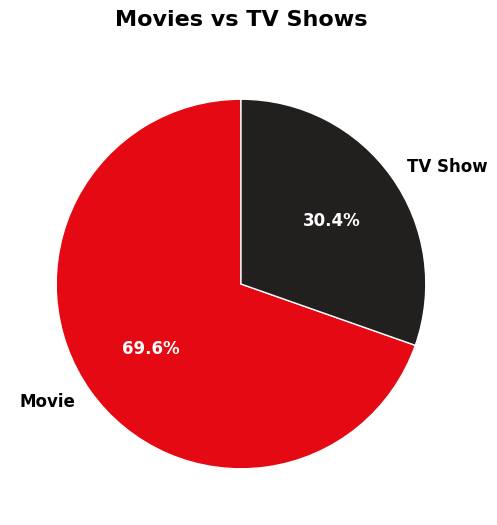

In [51]:

netflix_colors = ['#E50914', '#221F1F']

plt.figure(figsize=(6,6))

patches, texts, autotexts = plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=netflix_colors, # Apply the theme colors
    wedgeprops={'edgecolor': 'white', 'linewidth': 1} # Optional: adds a thin white border
)

for text in autotexts:
    text.set_color('white')
    text.set_weight('bold')
    text.set_fontsize(12)

for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

plt.title("Movies vs TV Shows", fontsize=16, fontweight='bold', pad=20)
plt.show()

Netflix focuses more on movies than series, possibly due to lower production cost and faster release cycles.

<h3>2.  Which year added the most titles to Netflix?<h3>

In [52]:

df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year
year_counts = df['year_added'].value_counts()
print(f"\nYear with most titles added: {int(year_counts.idxmax())} ({year_counts.max()} titles)")


Year with most titles added: 2019 (2019 titles)


C:\Users\DELL\AppData\Local\Temp\ipykernel_26232\836063055.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=year_counts.index.astype(int), y=year_counts.values, palette=colors)


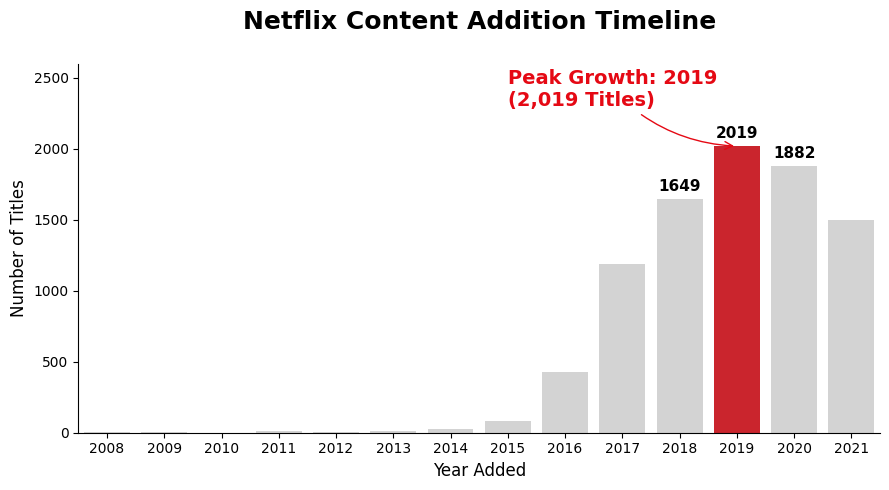

In [53]:

df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year
year_counts = df['year_added'].value_counts().sort_index()

colors = ['#E50914' if year == 2019 else '#D3D3D3' for year in year_counts.index]

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=year_counts.index.astype(int), y=year_counts.values, palette=colors)

plt.ylim(0, 2600)
plt.annotate('Peak Growth: 2019\n(2,019 Titles)',
             xy=(year_counts.index.get_loc(2019), 2019),
             xytext=(year_counts.index.get_loc(2019)-4, 2300),
             fontsize=14, fontweight='bold', color='#E50914',
             arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", color='#E50914', lw=1))

# Styling
plt.title('Netflix Content Addition Timeline', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Year Added', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)

for p in ax.patches:
    height = p.get_height()
    if height > 1500: # Only label major peaks
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

<h3> 3. Which countries produce the most Netflix content?<h3>

In [54]:

top_countries = df['country'].value_counts().head(10)
print("\nTop 10 Countries:")
print(top_countries)


Top 10 Countries:
country
United States     3649
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


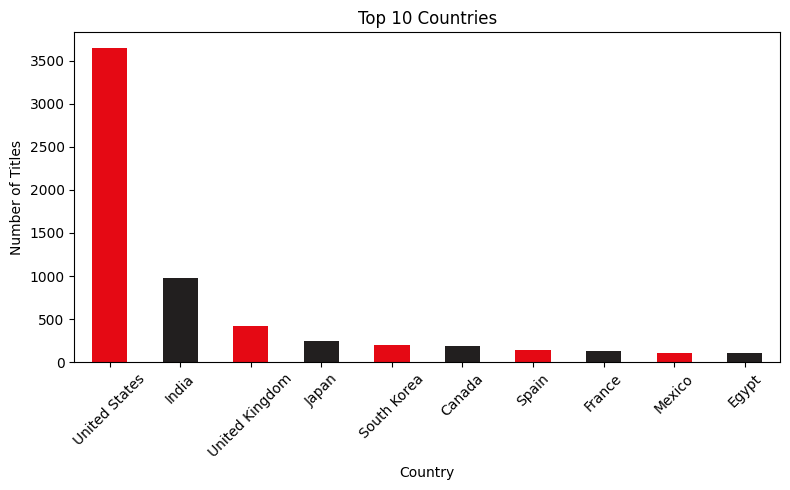

In [55]:
top_countries .plot(kind='bar',
                        stacked=True,
                        figsize=(8,5),
                        color=['#E50914',  '#221F1F'])

plt.title("Top 10 Countries")
plt.ylabel("Number of Titles")
plt.xlabel("Country")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Netflix content is heavily centered around a few countries, showing limited global diversity despite being a global platform.

<h3> 4. What are the most common genres? <h3>

In [56]:
# I split the 'listed_in' column because one title can belong to multiple genres
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)
print("\nTop 10 Genres:")
print(top_genres)


Top 10 Genres:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


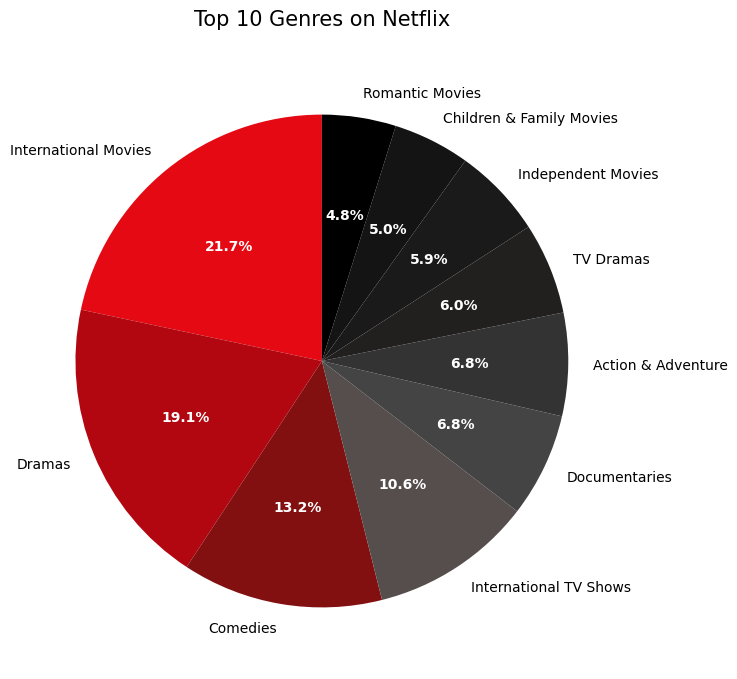

In [57]:

netflix_colors = [
    '#E50914', '#B20710', '#831010',
    '#564D4D', '#444444', '#333333',
    '#221F1F', '#1A1A1A', '#141414', '#000000'
]

plt.figure(figsize=(8,8))

patches, texts, autotexts = plt.pie(
    top_genres,
    labels=top_genres.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=netflix_colors
)

for text in autotexts:
    text.set_color('white')
    text.set_weight('bold')

plt.title("Top 10 Genres on Netflix", fontsize=15, pad=20)
plt.show()

🎭 Most Popular Genres

Common genres:

Dramas

Comedies

International Movies

Insight:

Netflix prioritizes emotionally engaging and widely relatable genres to appeal to global audiences.

<h1>Top 5 Genres Over The Last 5 years</h1>

C:\Users\DELL\AppData\Local\Temp\ipykernel_26232\3187866353.py:20: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.lineplot(


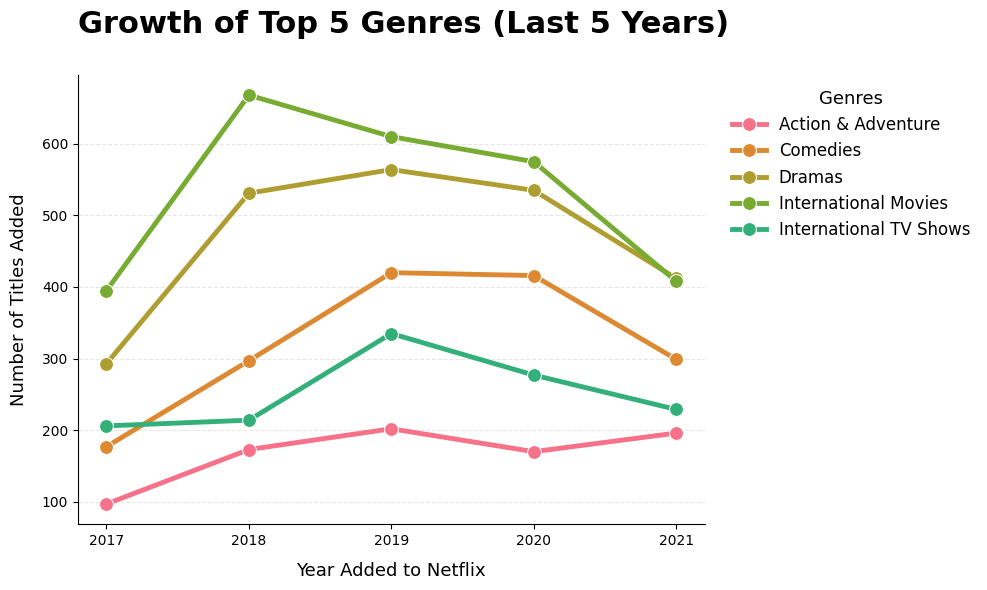

In [58]:

dfcpy = df[['title', 'date_added', 'listed_in']].copy()
dfcpy['date_added'] = pd.to_datetime(dfcpy['date_added'])
dfcpy['year_added'] = dfcpy['date_added'].dt.year

max_year = dfcpy['year_added'].max()
recent_years = dfcpy[dfcpy['year_added'] >= (max_year - 4)].copy()

recent_years['listed_in'] = recent_years['listed_in'].str.split(', ')
recent_years = recent_years.explode('listed_in')

top_5_overall = recent_years['listed_in'].value_counts().nlargest(5).index
plot_data = recent_years[recent_years['listed_in'].isin(top_5_overall)]

genre_trends = plot_data.groupby(['year_added', 'listed_in']).size().reset_index(name='count')

plt.figure(figsize=(10, 6))

palette = sns.color_palette("husl", 10)

sns.lineplot(
    data=genre_trends,
    x='year_added',
    y='count',
    hue='listed_in',
    linewidth=3.5,
    marker='o',
    markersize=10,
    palette=palette
)

plt.title("Growth of Top 5 Genres (Last 5 Years)", fontsize=22, fontweight='bold', pad=30, loc='left')
plt.xlabel("Year Added to Netflix", fontsize=13, labelpad=10)
plt.ylabel("Number of Titles Added", fontsize=13, labelpad=10)

plt.xticks(range(int(max_year-4), int(max_year+1)))

plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()

plt.legend(
    title="Genres",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False,
    fontsize=12,
    title_fontsize=13
)

plt.tight_layout()
plt.show()

<h2>Time Trend Analysis<h2>

<h3>How has Netflix content grown over the years? </h3>

In [59]:

df['date_added'] = pd.to_datetime(df['date_added'])
df['added_year'] = df['date_added'].dt.year
growth_over_years = df['added_year'].value_counts().sort_index() #.head(10)
print(growth_over_years)

added_year
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1192
2018    1649
2019    2019
2020    1882
2021    1498
Name: count, dtype: int64


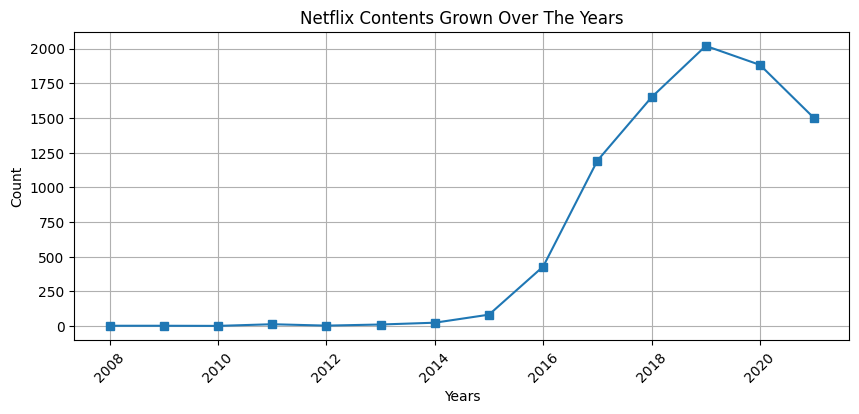

In [60]:
plt.figure(figsize =(10, 4))

plt.plot(growth_over_years.index,
         growth_over_years.values,
         marker="s")


plt.xticks(rotation = 45)
plt.title("Netflix Contents Grown Over The Years")
plt.xlabel("Years")
plt.ylabel("Count")

plt.grid(True)
plt.show()

Netflix aggressively expanded its library during these years, likely due to global competition (e.g., streaming wars).

<h3>Which release year has the most titles? </h3>

In [61]:

top_release_year = df['release_year'].value_counts().idxmax()
top_release_count = df['release_year'].value_counts().max()
print("The top release year is ", top_release_year)
print ("The top release count is ", top_release_count)

The top release year is  2018
The top release count is  1147


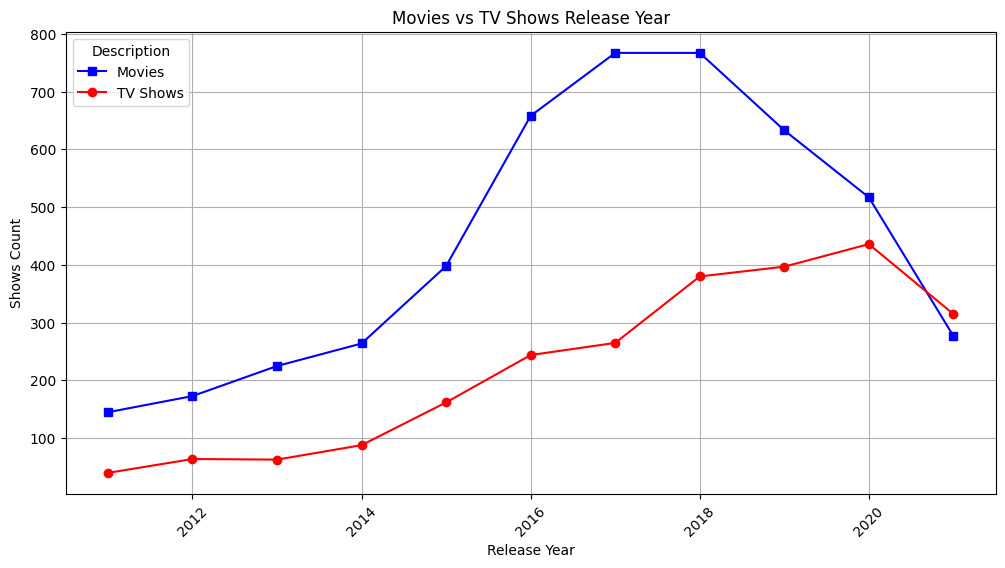

In [62]:

release_yr_count =  (
                    df.groupby(["type", "release_year"])
                    .size()
                 .reset_index(name="count")

                    )


pivot_release_yr_count = release_yr_count.pivot(index="release_year", columns="type", values="count").tail(11)

plt.figure(figsize =(12, 6))

plt.plot(pivot_release_yr_count.index,
         pivot_release_yr_count["Movie"],#instead of .values
         marker="s",
         color="blue",
         label="Movies"

         )
plt.plot(pivot_release_yr_count.index,
         pivot_release_yr_count["TV Show"],#instead of .values
         marker="o",
         color="red",
         label="TV Shows"

         )

plt.xticks(rotation = 45)
plt.title("Movies vs TV Shows Release Year")
plt.xlabel("Release Year")
plt.ylabel("Shows Count")
plt.legend(loc="upper left", title="Description")


plt.grid(True)
plt.show()


<h3>Is Netflix adding more TV shows or movies recently?</h3>

In [63]:
# Focus on the last 5 years of additions
df['date_added'] = pd.to_datetime(df['date_added'])
df['added_year'] = df['date_added'].dt.year

recent_years = df[df['added_year'] >= (df['added_year'].max() - 5)]
# netflix dataset လိုမျိုးက အချိန်နဲ့အလိုက် ထပ်တိုးနေတာမို့ added_year ကို 5 steps back လုပ်ထားတယ်။ instead of using 2017 or 1016.

recent_comparison = recent_years.groupby(['added_year', 'type']).size().unstack().fillna(0).astype(int)
print("Content Added to Netflix (Last 5 Years):")
print(recent_comparison)

Content Added to Netflix (Last 5 Years):
type        Movie  TV Show
added_year                
2016          253      176
2017          839      353
2018         1237      412
2019         1424      595
2020         1284      598
2021          993      505


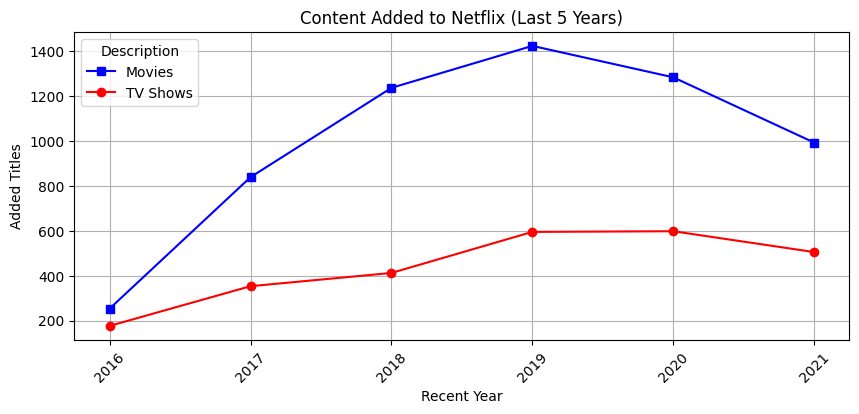

In [64]:
plt.figure(figsize =(10, 4))

plt.plot(recent_comparison.index,
         recent_comparison["Movie"],
         marker="s",
         color="blue",
         label="Movies"

         )
plt.plot(recent_comparison.index,
         recent_comparison["TV Show"],
         marker="o",
         color="red",
         label="TV Shows"

         )

plt.xticks(rotation = 45)
plt.title("Content Added to Netflix (Last 5 Years)")
plt.xlabel("Recent Year")
plt.ylabel("Added Titles")
plt.legend(loc="upper left", title="Description")


plt.grid(True)
plt.show()

<h1>Country Analysis</h1>

<h3>  Are movies or TV shows more common in each country?</h3>

In [65]:

top_10_countries = df['country'].value_counts().head(10).index

df_top = df[df['country'].isin(top_10_countries)]

country_comparison = df_top.groupby(['country', 'type']).size().unstack(fill_value = 0)
# .unstack ပဲသုံးမယ်ဆိုရင် fillလုပ်မှာက NaN ဖြစ်လိမ့်မယ်
country_comparison['Total'] = country_comparison['Movie'] + country_comparison['TV Show']
country_comparison = country_comparison.sort_values(by='Total', ascending=False)

print("Top 10 Countries Content Breakdown:")
print(country_comparison[['Movie', 'TV Show', 'Total']])

Top 10 Countries Content Breakdown:
type            Movie  TV Show  Total
country                              
United States    2498     1151   3649
India             893       79    972
United Kingdom    206      213    419
Japan              76      169    245
South Korea        41      158    199
Canada            122       59    181
Spain              97       48    145
France             75       49    124
Mexico             70       40    110
Egypt              92       14    106


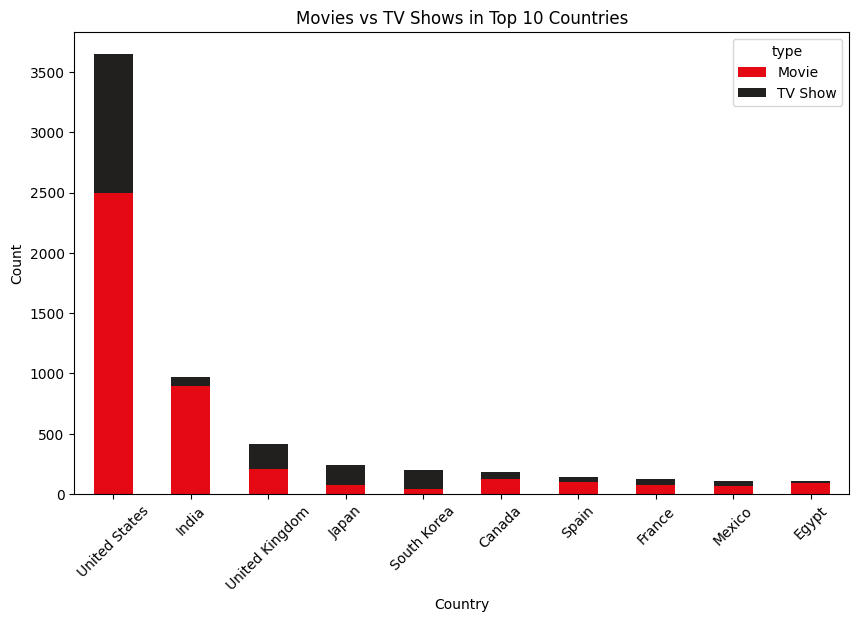

In [66]:


country_comparison[['Movie', 'TV Show']].plot(kind='bar', stacked=True, figsize=(10,6), color=['#E50914', '#221F1F'])

plt.title('Movies vs TV Shows in Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

2. Are movies or TV shows more common in each country?

Movie-Dominant: * India

United States, Canada, and Egypt also produce significantly more movies.

TV Show-Dominant: * Japan and South Korea are the exceptions. In these countries, TV Shows (Anime and K-Dramas) are much more common than movies on Netflix.

The "Balanced" Country:

The United Kingdom , a nearly 50/50 split between Movies and TV Shows.

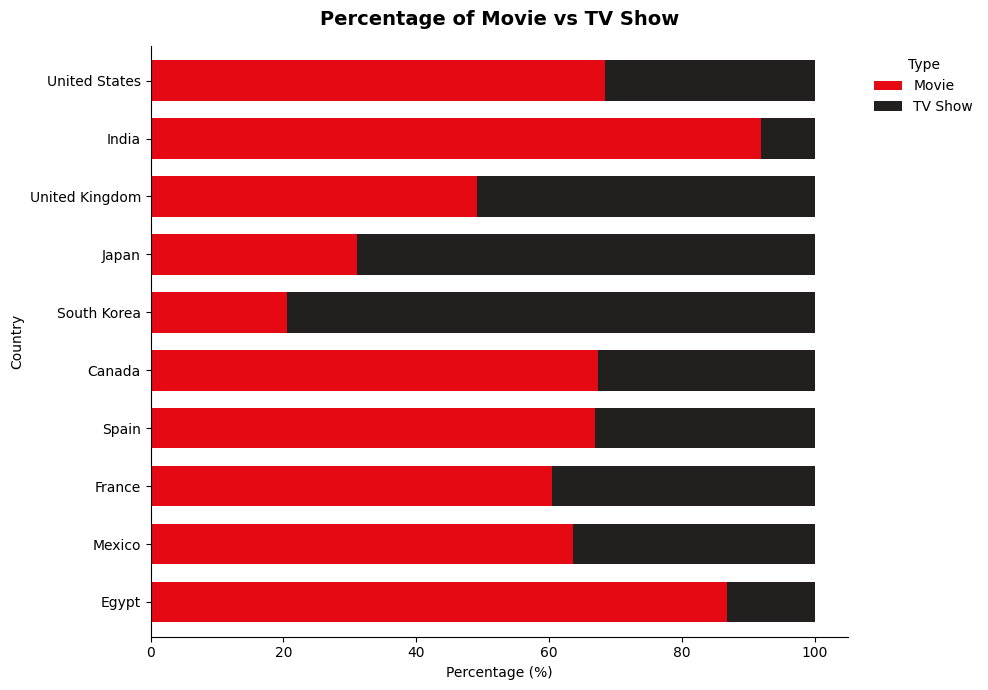

In [67]:

country_comparison_sorted = country_comparison.sort_values(by='Total', ascending=True)

country_perc = country_comparison_sorted[['Movie', 'TV Show']].div(country_comparison_sorted['Total'], axis=0) * 100


plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 7))

country_perc.plot(
    kind='barh',
    stacked=True,
    color=['#e50914', '#221f1f'],
    ax=ax,
    width=0.7
)

plt.title('Percentage of Movie vs TV Show', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Percentage (%)')
plt.ylabel('Country')

plt.legend(title="Type", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

<h1>Movies vs TV Shows Added (Recent Years)</h1>

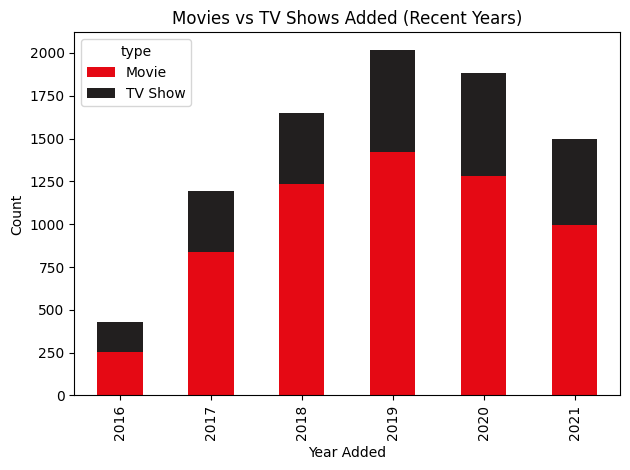

In [68]:

plt.subplot(1, 1, 1)


recent_comparison.plot(kind='bar',
                        stacked=True,
                        ax=plt.gca(),
                        color=['#E50914',
                         '#221F1F'])


plt.title('Movies vs TV Shows Added (Recent Years)')

plt.xlabel('Year Added')

plt.ylabel('Count')


plt.tight_layout()
plt.show()

<h2>Ratings Analysis</h2>

<h3>Most common content ratings (Univariate)</h3>

In [69]:
top_ratings = df['rating'].value_counts()

# print("Top 5 Content Ratings on Netflix:")
print(top_ratings.head(5))

rating
TV-MA    3211
TV-14    2160
TV-PG     863
R         799
PG-13     492
Name: count, dtype: int64


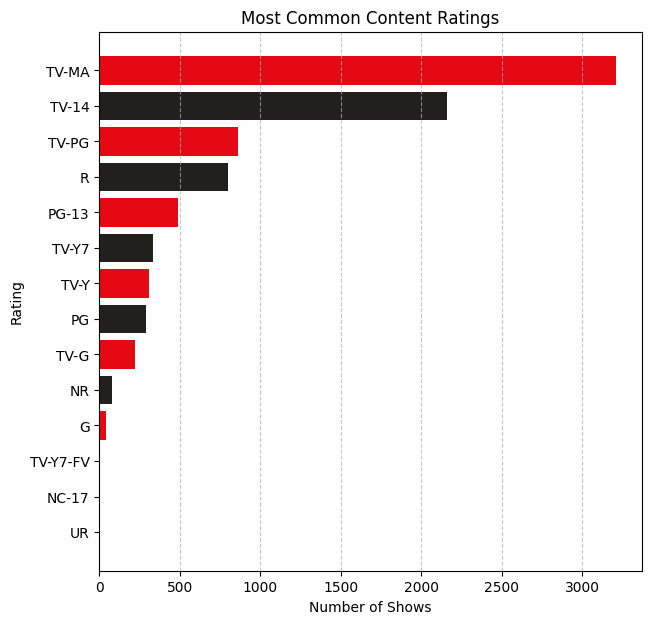

In [70]:
top10_ratings = df['rating'].value_counts()

plt.figure(figsize=(7, 7))
plt.barh(top10_ratings.index,top10_ratings.values, color=['#E50914', '#221F1F'])

plt.title("Most Common Content Ratings")
plt.xlabel("Number of Shows")
plt.ylabel("Rating")
plt.grid(axis="x", linestyle="--", alpha=0.7)

# highest is on top
plt.gca().invert_yaxis()

plt.show()


<h1>Rating by Country</h1>

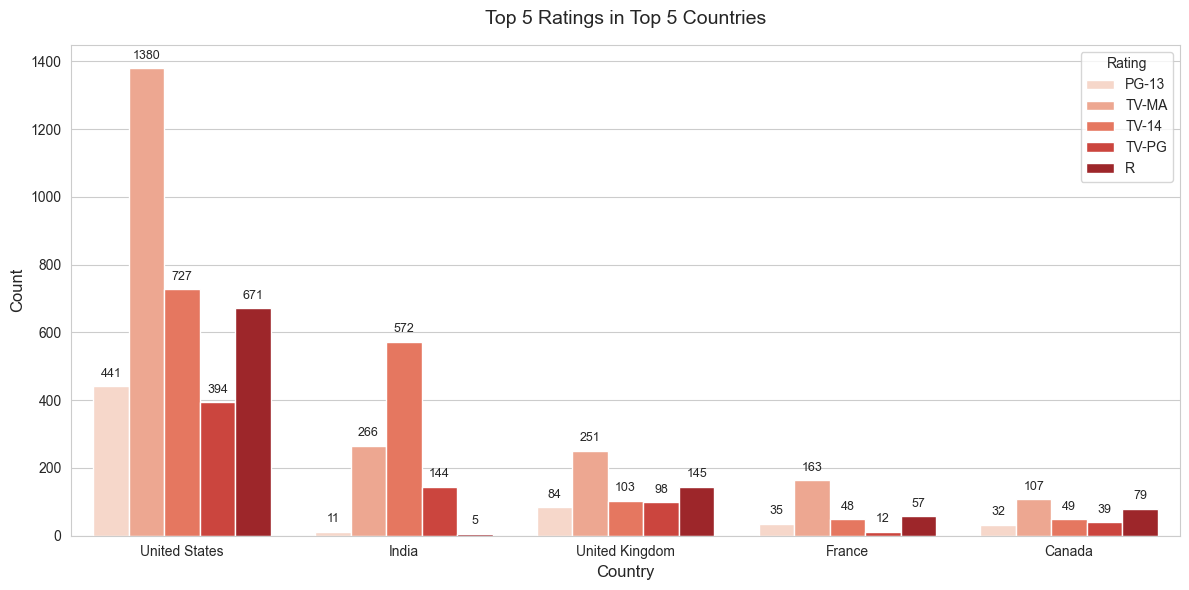

In [71]:

top_5_ratings = df['rating'].value_counts().head(5).index
df_simple = df[df['rating'].isin(top_5_ratings)].copy()


df_simple['country'] = df_simple['country'].str.split(', ')
df_simple = df_simple.explode('country')
top_5_countries = df_simple['country'].value_counts().head(5).index
df_simple = df_simple[df_simple['country'].isin(top_5_countries)]


plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")


ax = sns.countplot(
    data=df_simple,
    x='country',
    hue='rating',
  palette='Reds',
    order=top_5_countries
)


plt.title("Top 5 Ratings in Top 5 Countries", fontsize=14, pad=15)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Rating", loc='upper right')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points',
                    fontsize=9)

plt.tight_layout()
plt.show()

⭐ Ratings Distribution

Most content is rated:

TV-MA

TV-14

Insight:

Netflix targets a more mature audience, with fewer shows for children.

<h2>Duration Analysis</h2>

In [72]:

movies_df = df[df['type'] == 'Movie'].copy()
tv_shows_df = df[df['type'] == 'TV Show'].copy()


avg_duration = movies_df['duration_no'].mean()
print(f"- The average movie duration is: {avg_duration:.2f} minutes")

season_counts = tv_shows_df['duration_no'].mode()[0]
print(f"- Most TV Shows have commonly: {season_counts} Season(s)")




- The average movie duration is: 99.56 minutes
- Most TV Shows have commonly: 1 Season(s)


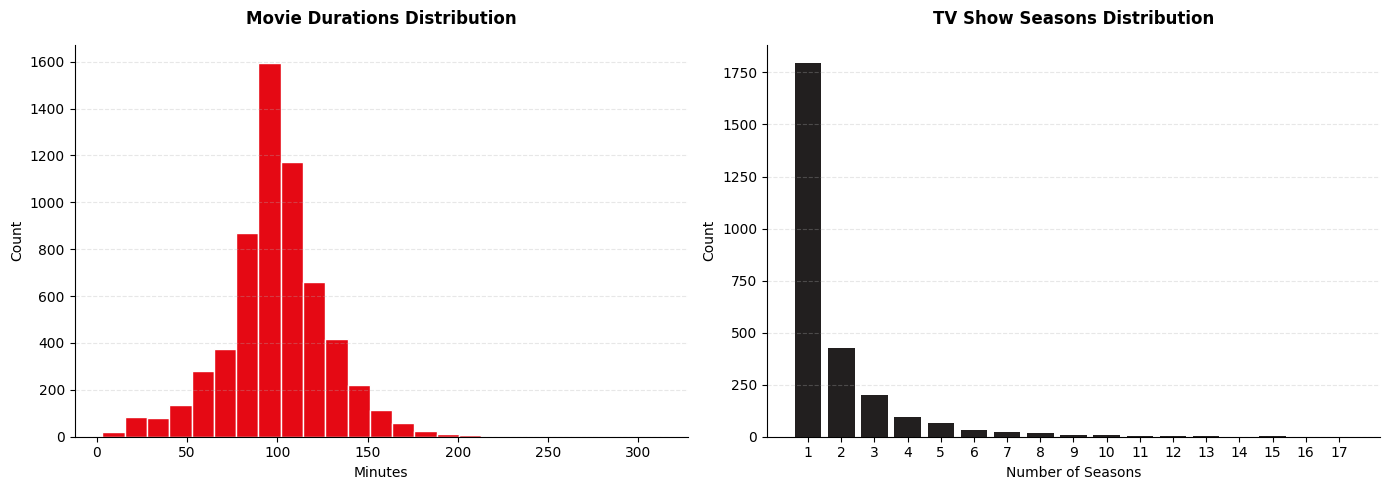

In [73]:


movies_df = df[df['type'] == 'Movie'].copy()
tv_shows_df = df[df['type'] == 'TV Show'].copy()

m_duration = movies_df['duration_no'].dropna()
tv_seasons = tv_shows_df['duration_no'].dropna()

plt.style.use('default')
fig, axs = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

axs[0].hist(m_duration, bins=25, color="#e50914", edgecolor="white")
axs[0].set_title("Movie Durations Distribution", fontweight='bold', pad=15)
axs[0].set_xlabel("Minutes")
axs[0].set_ylabel("Count")

counts = tv_seasons.value_counts().sort_index()
axs[1].bar(counts.index, counts.values, color="#221f1f")
axs[1].set_title("TV Show Seasons Distribution", fontweight='bold', pad=15)
axs[1].set_xlabel("Number of Seasons")
axs[1].set_ylabel("Count")
axs[1].set_xticks(range(1, int(tv_seasons.max()) + 1))

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

⏱️ Duration Analysis

Movies:

Mostly around 90–120 minutes

TV Shows:

Usually 1–2 seasons

Insight:

Netflix favors shorter, binge-friendly content rather than long-running series.

<Figure size 1200x600 with 0 Axes>

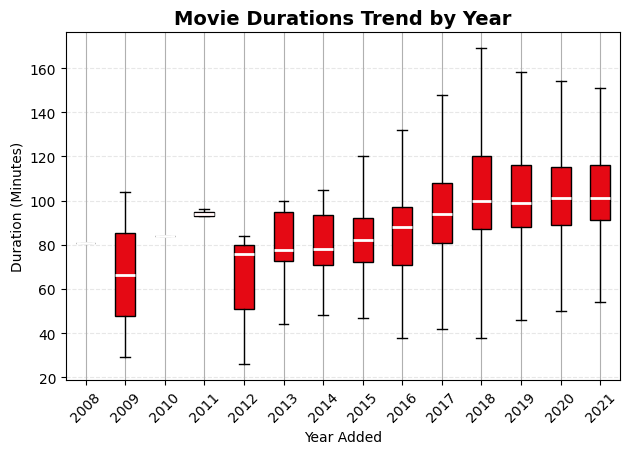

In [74]:
plt.figure(figsize=(12, 6))

movies_df.boxplot(
    column="duration_no",
    by="added_year",
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor="#E50914", color="black"),
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black")
)

plt.title("Movie Durations Trend by Year", fontsize=14, fontweight="bold", color="#000000")
plt.suptitle("")
plt.xlabel("Year Added")
plt.ylabel("Duration (Minutes)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

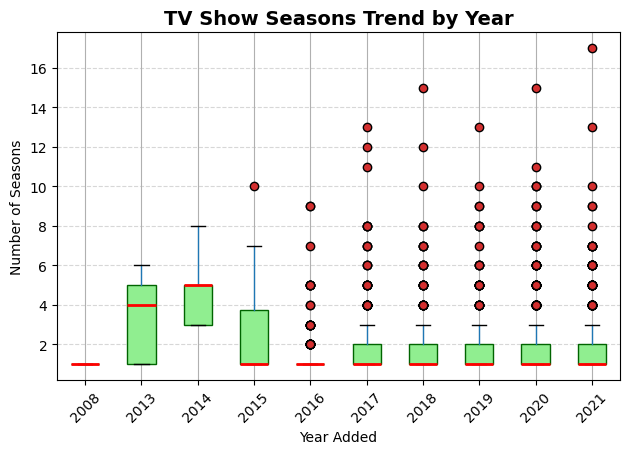

In [75]:

plt.figure(figsize=(12, 6))

tv_shows_df.boxplot(
    column="duration_no",
    by="added_year",
    patch_artist=True,
    showfliers=True,


    flierprops=dict(
        marker='o',
        markerfacecolor='#d32f2f',
        markersize=6,
        linestyle='none',
        markeredgecolor='black'
    ),

    boxprops=dict(facecolor="lightgreen", color="darkgreen"),
    medianprops=dict(color="red", linewidth=2),
)

plt.title("TV Show Seasons Trend by Year", fontsize=14, fontweight="bold")
plt.suptitle("")
plt.xlabel("Year Added")
plt.ylabel("Number of Seasons")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Director / Cast Analysis

In [76]:
# Top Directors
# We drop rows with no director listed to get accurate rankings
directors = df['director'].dropna().str.split(', ').explode()
top_10_directors = directors.value_counts().head(10)
print(top_10_directors)

director
unknown                2634
Rajiv Chilaka            22
Jan Suter                21
Raúl Campos              19
Suhas Kadav              16
Marcus Raboy             16
Jay Karas                15
Cathy Garcia-Molina      13
Youssef Chahine          12
Martin Scorsese          12
Name: count, dtype: int64


In [77]:
#  Top Actors
actors = df['cast'].dropna().str.split(', ').explode()
top_10_actors = actors.value_counts().head(10)
print(top_10_actors)

cast
unknown             825
Anupam Kher          43
Shah Rukh Khan       35
Julie Tejwani        33
Naseeruddin Shah     32
Takahiro Sakurai     32
Rupa Bhimani         31
Akshay Kumar         30
Om Puri              30
Yuki Kaji            29
Name: count, dtype: int64


<h3> Percentage of the Top 5 Countries' Ratings on Movies</h3>

In [78]:

movies_df = df[df['type'] == 'Movie'].copy()
top_5_countries = movies_df['country'].value_counts().head(5).index

subset = movies_df[movies_df['country'].isin(top_5_countries)]

result = (
    subset.groupby('country')['rating']
    .apply(lambda x: pd.Series({
        'total_movie': len(x),
        'common_rating': x.mode()[0],
        'percentage': f"{(x.value_counts().max() / len(x) * 100):.1f}%"
    }))
)

print(result)

country                      
Canada          total_movie        122
                common_rating    TV-MA
                percentage       34.4%
India           total_movie        893
                common_rating    TV-14
                percentage       58.9%
Spain           total_movie         97
                common_rating    TV-MA
                percentage       83.5%
United Kingdom  total_movie        206
                common_rating    TV-MA
                percentage       42.2%
United States   total_movie       2498
                common_rating    TV-MA
                percentage       30.2%
Name: rating, dtype: object


<h3> Percentage of the Top 5 Countries' movies distribution </h3>

In [79]:
movies_df = df[df['type'] == 'Movie'].copy()

top_5_countries = movies_df['country'].value_counts().head(5).index

subset = movies_df[movies_df['country'].isin(top_5_countries)]

result = subset.groupby('country')['listed_in'].apply(lambda x: (
    pd.Series([genre.strip() for s in x for genre in s.split(',')])
    .pipe(lambda s: pd.Series({
        'total_movie': len(x),
        'common_genre': s.mode()[0],
        'percentage': f"{(s.value_counts().max() / len(x) * 100):.1f}%"
    }))
))

print(result)

country                     
Canada          total_movie                      122
                common_genre                Comedies
                percentage                     32.0%
India           total_movie                      893
                common_genre    International Movies
                percentage                     91.5%
Spain           total_movie                       97
                common_genre    International Movies
                percentage                     92.8%
United Kingdom  total_movie                      206
                common_genre           Documentaries
                percentage                     40.8%
United States   total_movie                     2498
                common_genre                  Dramas
                percentage                     28.1%
Name: listed_in, dtype: object


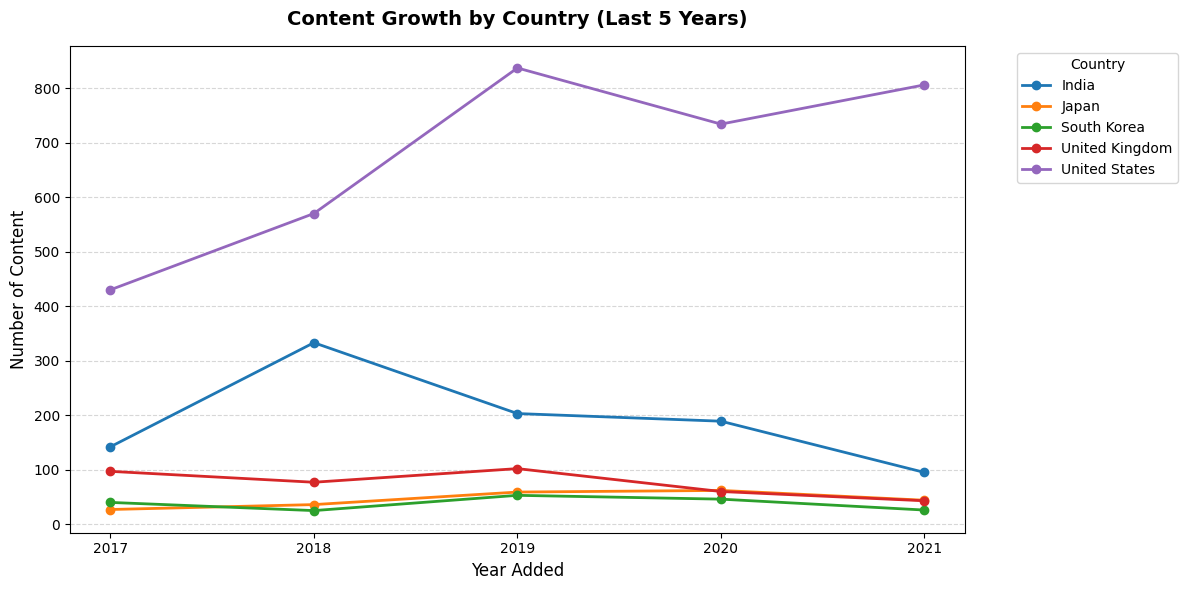

In [80]:
import matplotlib.pyplot as plt

last_5_years = [2017, 2018, 2019, 2020, 2021]
df_recent = df[df['added_year'].isin(last_5_years)]

top_5_countries = df['country'].value_counts().head(5).index
df_top_5 = df_recent[df_recent['country'].isin(top_5_countries)]

growth_data = df_top_5.groupby(['added_year', 'country']).size().unstack()

plt.figure(figsize=(12, 6))
growth_data.plot(kind='line', marker='o', ax=plt.gca(), linewidth=2)

plt.title('Content Growth by Country (Last 5 Years)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year Added', fontsize=12)
plt.ylabel('Number of Content', fontsize=12)
plt.xticks(last_5_years) 
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<h1> Correlation / Insights </h1>

Which countries produce the most movies vs TV shows?

What genre is most common in recent years?



Netflix content success/design is not dependent on a single factor (like duration or year alone).


Netflix is shifting toward international content (increase in non-US titles over time).

More TV Shows are being added in recent years → trend shift.

Global expansion

binge culture focus

mature audience targeting

“From the analysis, we can see that Netflix focuses heavily on movies and mature content, with the United States leading production. However, in recent years, there has been a noticeable increase in international content, showing Netflix’s global expansion strategy.”

In [81]:
df.to_csv('netflix_cleaned_dataset.csv',index=False)
print("csv file has been saved successfully.")

csv file has been saved successfully.
